# U1 - Integrante 3 - Clasificación de Rol (is_buyer_maker)

Pipeline Bronze → Silver → Gold con PySpark, entrenamiento y comparación de modelos de clasificación binaria (Logistic Regression vs GBT Classifier).

## 1. Configuración Spark

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, LongType, DoubleType, BooleanType
from pyspark.sql.functions import col, when
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.classification import LogisticRegression, GBTClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator

spark = (
    SparkSession.builder
        .appName("U1-Integrante3-ClasificacionRol")
        .master("local[*]")
        .config("spark.ui.port", "4040")
        .config("spark.sql.shuffle.partitions", "8")
        .config("spark.driver.memory", "4g")
        .getOrCreate()
)

spark

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/11 19:41:16 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## 2. Carga Bronze

In [2]:
schema = StructType([
    StructField("trade_id", LongType(), False),
    StructField("price", DoubleType(), True),
    StructField("qty", DoubleType(), True),
    StructField("quote_qty", DoubleType(), True),
    StructField("time_us", LongType(), False),
    StructField("is_buyer_maker", BooleanType(), True),
    StructField("is_best_match", BooleanType(), True)
])

df_bronze = spark.read.csv("/opt/data/BTCUSDT-trades-2026-01-05.csv", schema=schema, header=False)
df_bronze.printSchema()
df_bronze.show(5)

root
 |-- trade_id: long (nullable = true)
 |-- price: double (nullable = true)
 |-- qty: double (nullable = true)
 |-- quote_qty: double (nullable = true)
 |-- time_us: long (nullable = true)
 |-- is_buyer_maker: boolean (nullable = true)
 |-- is_best_match: boolean (nullable = true)

+----------+--------+-------+-----------+----------------+--------------+-------------+
|  trade_id|   price|    qty|  quote_qty|         time_us|is_buyer_maker|is_best_match|
+----------+--------+-------+-----------+----------------+--------------+-------------+
|5734054604|91529.74| 2.2E-4| 20.1365428|1767571200308618|         false|         true|
|5734054605|91529.74|   0.01|   915.2974|1767571200375801|         false|         true|
|5734054606|91529.74|0.00437|399.9849638|1767571200477157|         false|         true|
|5734054607|91529.74|0.00764|699.2872136|1767571200480543|         false|         true|
|5734054608|91529.74|0.00136|124.4804464|1767571200545508|         false|         true|
+--------

## 3. Capa Silver

In [3]:
df_silver = df_bronze.na.drop(subset=["trade_id", "price", "is_buyer_maker"]) \
    .dropDuplicates(["trade_id"]) \
    .withColumn("label", when(col("is_buyer_maker") == True, 1.0).otherwise(0.0))

df_silver.show(5)

[Stage 1:====================================================>     (9 + 1) / 10]

+----------+--------+-------+-------------+----------------+--------------+-------------+-----+
|  trade_id|   price|    qty|    quote_qty|         time_us|is_buyer_maker|is_best_match|label|
+----------+--------+-------+-------------+----------------+--------------+-------------+-----+
|5734054604|91529.74| 2.2E-4|   20.1365428|1767571200308618|         false|         true|  0.0|
|5734054610|91529.74| 5.4E-4|   49.4260596|1767571200665868|         false|         true|  0.0|
|5734054624|91529.74|0.20378|18651.9304172|1767571202033686|         false|         true|  0.0|
|5734054642|91529.73|0.00599|  548.2630827|1767571202551395|          true|         true|  1.0|
|5734054646|91529.74| 9.0E-5|    8.2376766|1767571202941974|         false|         true|  0.0|
+----------+--------+-------+-------------+----------------+--------------+-------------+-----+
only showing top 5 rows


## 4. Capa Gold Parquet

In [4]:
df_silver.write.mode("overwrite").partitionBy("is_best_match").parquet("/opt/artifacts/gold_integrante3")
df_gold = spark.read.parquet("/opt/artifacts/gold_integrante3")
df_gold.show(5)

+----------+--------+-------+-----------+----------------+--------------+-----+-------------+
|  trade_id|   price|    qty|  quote_qty|         time_us|is_buyer_maker|label|is_best_match|
+----------+--------+-------+-----------+----------------+--------------+-----+-------------+
|5734054606|91529.74|0.00437|399.9849638|1767571200477157|         false|  0.0|         true|
|5734054617|91529.74| 9.6E-4| 87.8685504|1767571201602432|         false|  0.0|         true|
|5734054630|91529.74| 1.1E-4| 10.0682714|1767571202085489|         false|  0.0|         true|
|5734054637|91529.73| 4.7E-4| 43.0189731|1767571202435549|          true|  1.0|         true|
|5734054644|91529.73|0.00476|435.6815148|1767571202744883|          true|  1.0|         true|
+----------+--------+-------+-----------+----------------+--------------+-----+-------------+
only showing top 5 rows


## 5. VectorAssembler & Scaler

In [5]:
assembler = VectorAssembler(inputCols=["price", "qty", "quote_qty"], outputCol="features")
df_ml = assembler.transform(df_gold).select("features", "label")

df_train, df_test = df_ml.randomSplit([0.8, 0.2], seed=42)

## 6. Modelado Comparativo

In [6]:
lr = LogisticRegression(featuresCol="features", labelCol="label")
modelo_lr = lr.fit(df_train)
pred_lr = modelo_lr.transform(df_test)

gbt = GBTClassifier(featuresCol="features", labelCol="label", maxIter=10)
modelo_gbt = gbt.fit(df_train)
pred_gbt = modelo_gbt.transform(df_test)

netlib-blas: JNI_OnLoad: dlopen(libblas.so.3) failed: libblas.so.3: cannot open shared object file: No such file or directory
                                                                                

## 7. Evaluación AUC

In [7]:
evaluator = BinaryClassificationEvaluator(metricName="areaUnderROC")
print(f"Logistic Regression AUC: {evaluator.evaluate(pred_lr):.4f}")
print(f"GBT Classifier AUC: {evaluator.evaluate(pred_gbt):.4f}")

Logistic Regression AUC: 0.5299


GBT Classifier AUC: 0.5576


## 8. Guardar Artefacto Ganador

In [8]:
modelo_gbt.write().overwrite().save("/opt/artifacts/modelo_ganador_integrante3")

# 9. VISUALIZACIÓN DE RESULTADOS Y MÉTRICAS

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve

/usr/local/lib/python3.10/site-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)
/usr/local/lib/python3.10/site-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)
                                                                                

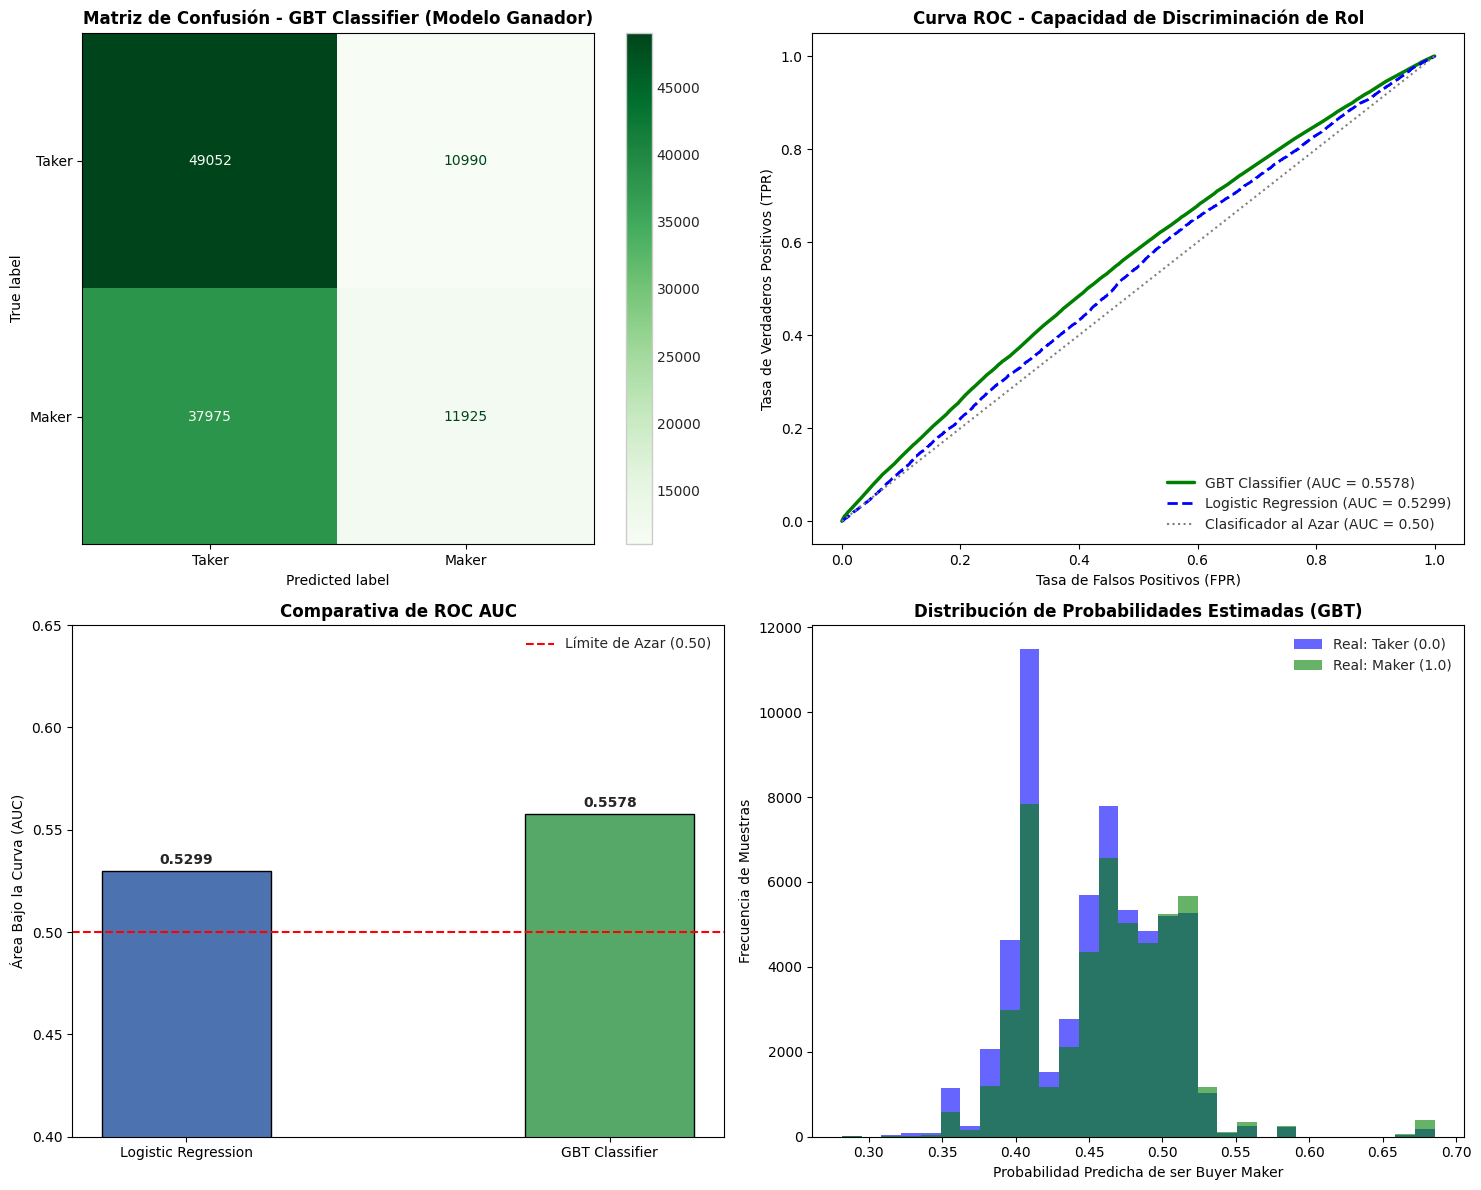

In [10]:
sample_lr = pred_lr.select("label", "prediction", "probability").sample(withReplacement=False, fraction=0.1, seed=42).toPandas()
sample_gbt = pred_gbt.select("label", "prediction", "probability").sample(withReplacement=False, fraction=0.1, seed=42).toPandas()

sample_lr['prob_buyer_maker'] = sample_lr['probability'].apply(lambda x: float(x[1]))
sample_gbt['prob_buyer_maker'] = sample_gbt['probability'].apply(lambda x: float(x[1]))

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# -------------------------------------------------------------
# Gráfico 1: Matriz de Confusión - GBT Classifier (Ganador)
# -------------------------------------------------------------
cm_gbt = confusion_matrix(sample_gbt['label'], sample_gbt['prediction'])
disp_gbt = ConfusionMatrixDisplay(confusion_matrix=cm_gbt, display_labels=['Taker', 'Maker'])
disp_gbt.plot(ax=axes[0, 0], cmap='Greens', values_format='d')
axes[0, 0].set_title('Matriz de Confusión - GBT Classifier (Modelo Ganador)', fontsize=12, fontweight='bold')
axes[0, 0].grid(False)

# -------------------------------------------------------------
# Gráfico 2: Curva ROC (Comparativa LR vs GBT)
# -------------------------------------------------------------
fpr_lr, tpr_lr, _ = roc_curve(sample_lr['label'], sample_lr['prob_buyer_maker'])
fpr_gbt, tpr_gbt, _ = roc_curve(sample_gbt['label'], sample_gbt['prob_buyer_maker'])

axes[0, 1].plot(fpr_gbt, tpr_gbt, color='green', lw=2.5, label='GBT Classifier (AUC = 0.5578)')
axes[0, 1].plot(fpr_lr, tpr_lr, color='blue', lw=2, linestyle='--', label='Logistic Regression (AUC = 0.5299)')
axes[0, 1].plot([0, 1], [0, 1], color='gray', linestyle=':', label='Clasificador al Azar (AUC = 0.50)')

axes[0, 1].set_title('Curva ROC - Capacidad de Discriminación de Rol', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[0, 1].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
axes[0, 1].legend(loc='lower right')

# -------------------------------------------------------------
# Gráfico 3: Comparativa de AUC entre Modelos
# -------------------------------------------------------------
modelos = ['Logistic Regression', 'GBT Classifier']
auc_scores = [0.5299, 0.5578]
colors = ['#4C72B0', '#55A868']

bars = axes[1, 0].bar(modelos, auc_scores, color=colors, edgecolor='black', width=0.4)
axes[1, 0].axhline(y=0.50, color='red', linestyle='--', label='Límite de Azar (0.50)')
axes[1, 0].set_title('Comparativa de ROC AUC', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Área Bajo la Curva (AUC)')
axes[1, 0].set_ylim(0.4, 0.65)
axes[1, 0].legend()

for bar in bars:
    height = bar.get_height()
    axes[1, 0].annotate(f'{height:.4f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom', fontweight='bold', fontsize=10)

# -------------------------------------------------------------
# Gráfico 4: Distribución de Probabilidades Predichas por GBT
# -------------------------------------------------------------
axes[1, 1].hist(sample_gbt[sample_gbt['label'] == 0.0]['prob_buyer_maker'], bins=30, alpha=0.6, color='blue', label='Real: Taker (0.0)')
axes[1, 1].hist(sample_gbt[sample_gbt['label'] == 1.0]['prob_buyer_maker'], bins=30, alpha=0.6, color='green', label='Real: Maker (1.0)')

axes[1, 1].set_title('Distribución de Probabilidades Estimadas (GBT)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Probabilidad Predicha de ser Buyer Maker')
axes[1, 1].set_ylabel('Frecuencia de Muestras')
axes[1, 1].legend()

plt.tight_layout()
plt.show()